## 14 - Machine Learning Model

This notebook builds a logistic regression model to predict
whether a stock will outperform or underperform based purely
on CEO language from earnings calls.

### Research question
Can CEO sentiment and hedging language predict stock performance?

### Features (inputs)
- avg_compound: VADER sentiment score
- finbert_score: FinBERT financial sentiment score
- hedge_ratio: proportion of hedge words in transcript

### Label (output)
- 1 = Outperformed (positive 90-day return)
- 0 = Underperformed (negative 90-day return)

### Model
Logistic Regression — industry standard for binary classification

In [1]:
# Import libraries
import sqlite3
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

# Connect to database and load master table
conn = sqlite3.connect("../data/earnings_research.db")
df = pd.read_sql("SELECT * FROM master_analysis", conn)

print(f"Loaded {len(df)} records")
print(f"Columns: {list(df.columns)}")

Libraries imported successfully!
Loaded 75 records
Columns: ['ticker', 'quarter', 'date', 'period', 'hedge_ratio', 'earnings_price', 'return_30d', 'return_60d', 'return_90d', 'avg_compound', 'sentiment_hedge_gap', 'performance_90d', 'finbert_score', 'finbert_positive', 'finbert_negative']


In [2]:
# Prepare features and labels

# Remove SLB Q2 2023 which had empty transcript
df = df[df["avg_compound"] > 0].copy()

# Features - what we feed into the model
features = ["avg_compound", "finbert_score", "hedge_ratio"]
X = df[features].copy()

# Label - what we want to predict
# 1 = outperformed (positive 90-day return)
# 0 = underperformed (negative 90-day return)
y = (df["return_90d"] > 0).astype(int)

print(f"Total samples: {len(X)}")
print(f"\nFeatures shape: {X.shape}")
print(f"\nLabel distribution:")
print(f"Outperformed (1): {y.sum()} ({round(y.sum()/len(y)*100, 1)}%)")
print(f"Underperformed (0): {(y==0).sum()} ({round((y==0).sum()/len(y)*100, 1)}%)")
print(f"\nFeature statistics:")
print(X.describe().round(4))

Total samples: 74

Features shape: (74, 3)

Label distribution:
Outperformed (1): 43 (58.1%)
Underperformed (0): 31 (41.9%)

Feature statistics:
       avg_compound  finbert_score  hedge_ratio
count       74.0000        74.0000      74.0000
mean         0.2536         0.2301       0.0130
std          0.0700         0.2232       0.0027
min          0.0901        -0.4165       0.0063
25%          0.2136         0.1010       0.0110
50%          0.2530         0.2385       0.0131
75%          0.2947         0.3710       0.0151
max          0.4284         0.6702       0.0188


In [3]:
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

# Scale features - important for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train logistic regression model
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

print("\nModel trained successfully!")

# Evaluate on test set
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print(f"\nModel Accuracy: {round(accuracy * 100, 1)}%")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, 
      target_names=["Underperformed", "Outperformed"]))

Training samples: 59
Test samples: 15

Model trained successfully!

Model Accuracy: 60.0%

Classification Report:
                precision    recall  f1-score   support

Underperformed       0.33      0.20      0.25         5
  Outperformed       0.67      0.80      0.73        10

      accuracy                           0.60        15
     macro avg       0.50      0.50      0.49        15
  weighted avg       0.56      0.60      0.57        15



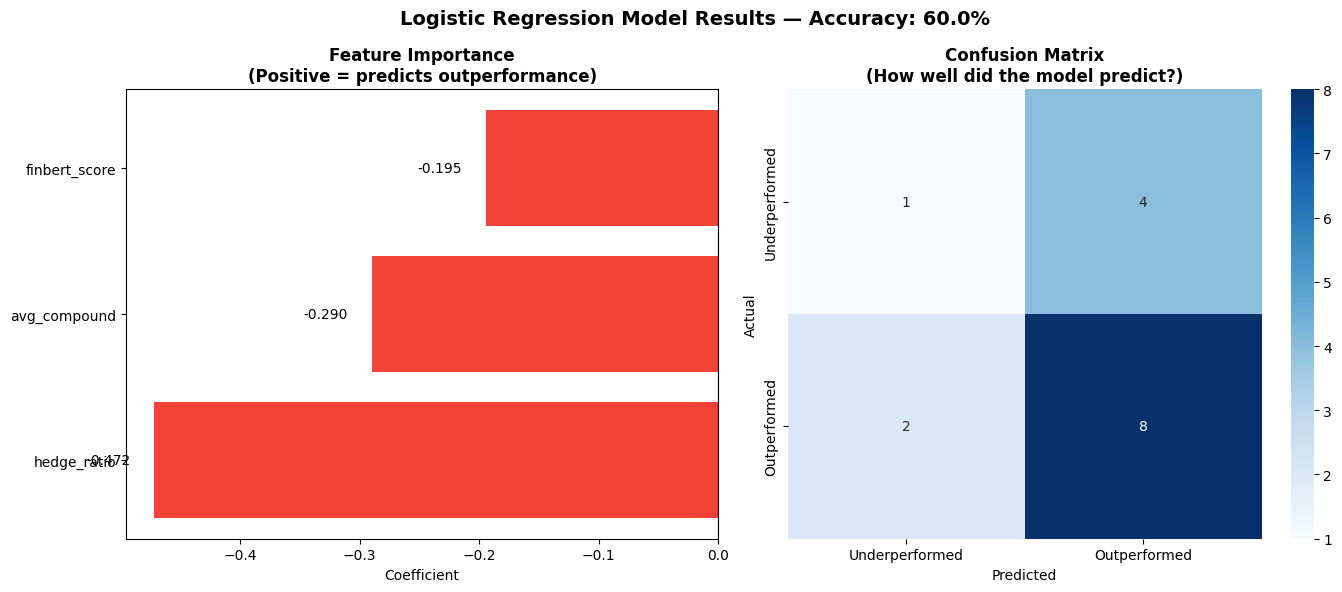

Chart saved!


In [4]:
# Feature importance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Feature coefficients
coef_df = pd.DataFrame({
    "feature": features,
    "coefficient": model.coef_[0]
}).sort_values("coefficient")

colors = ["#F44336" if c < 0 else "#4CAF50" for c in coef_df["coefficient"]]
bars = ax1.barh(coef_df["feature"], coef_df["coefficient"], color=colors)
ax1.axvline(x=0, color="black", linewidth=0.8)
ax1.set_title("Feature Importance\n(Positive = predicts outperformance)", 
              fontsize=12, fontweight="bold")
ax1.set_xlabel("Coefficient")
for bar, val in zip(bars, coef_df["coefficient"]):
    ax1.text(val + (0.02 if val >= 0 else -0.02),
             bar.get_y() + bar.get_height()/2,
             f"{val:.3f}", va="center", 
             ha="left" if val >= 0 else "right", fontsize=10)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Underperformed", "Outperformed"],
            yticklabels=["Underperformed", "Outperformed"],
            ax=ax2)
ax2.set_title("Confusion Matrix\n(How well did the model predict?)",
              fontsize=12, fontweight="bold")
ax2.set_ylabel("Actual")
ax2.set_xlabel("Predicted")

plt.suptitle(f"Logistic Regression Model Results — Accuracy: {round(accuracy*100, 1)}%",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/charts/06_ml_model_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved!")

In [6]:
# Show probability predictions for all 74 companies
X_all_scaled = scaler.transform(X)
probabilities = model.predict_proba(X_all_scaled)

df_predictions = df[["ticker", "quarter", "period", 
                      "avg_compound", "finbert_score", 
                      "hedge_ratio", "return_90d"]].copy()
df_predictions["prob_outperform"] = (probabilities[:, 1] * 100).round(1)
df_predictions["prob_underperform"] = (probabilities[:, 0] * 100).round(1)
df_predictions["predicted"] = model.predict(X_all_scaled)
df_predictions["actual"] = (df["return_90d"] > 0).astype(int)
df_predictions["correct"] = (df_predictions["predicted"] == df_predictions["actual"]).astype(int)

# Save to database
df_predictions.to_sql("ml_predictions", conn, if_exists="replace", index=False)
conn.commit()

# Show most interesting cases
print("=== Most likely to outperform (model's top picks) ===")
print(df_predictions.nlargest(10, "prob_outperform")[
    ["ticker", "quarter", "prob_outperform", "return_90d", "correct"]
].to_string(index=False))

print("\n=== Most likely to underperform (model's warnings) ===")
print(df_predictions.nlargest(10, "prob_underperform")[
    ["ticker", "quarter", "prob_underperform", "return_90d", "correct"]
].to_string(index=False))

=== Most likely to outperform (model's top picks) ===
ticker quarter  prob_outperform  return_90d  correct
    MS Q1_2020             81.3       54.10        1
  AMZN Q1_2020             80.9       22.62        1
 GOOGL Q1_2020             76.5       28.67        1
   HAL Q1_2020             76.1       97.40        1
  COST Q2_2023             76.1        0.08        1
  COST Q1_2020             75.8        5.97        1
   WFC Q1_2020             75.6       -1.69        0
   BAC Q1_2020             75.4       20.97        1
   MCD Q1_2020             73.3       17.41        1
   SLB Q2_2021             72.8       -7.88        0

=== Most likely to underperform (model's warnings) ===
ticker quarter  prob_underperform  return_90d  correct
   MCD Q2_2023               72.6      -10.14        1
    PG Q2_2023               68.0       -3.87        1
   UNH Q2_2023               60.9        5.41        0
   VLO Q1_2020               59.8       45.72        0
  MSFT Q4_2022               58.

In [7]:
conn.close()
print("Database connection closed.")

Database connection closed.
